In [1]:
import numpy as np
print(np.__version__)

1.26.4


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,roc_auc_score)
from sklearn.model_selection import GridSearchCV
import joblib

In [4]:
df = pd.read_csv("upi_fraud_dataset_10000.csv")
df

,UPI_Age_Days,Transaction_Amount,Transaction_Time,Transactions_Last_24Hrs,Failed_Transactions,New_Recipient,Device_Changed,Location_Changed,Multiple_UPI_Apps,Linked_Bank_Count,Fraud_Reported,Account_Verified,Fraud
0,3175,15805,14,42,7,0,0,0,0,5,0,1,1
1,1686,779,23,43,13,0,0,0,0,5,0,1,1
2,1083,18952,9,27,11,0,0,0,0,4,0,0,1
3,647,30750,8,38,1,1,1,0,0,5,0,1,1
4,3004,48565,7,46,2,1,0,0,0,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1259,38081,13,12,3,0,0,0,0,5,0,1,1
9996,45,19948,0,3,14,0,0,1,0,2,0,1,1
9997,606,4742,2,11,5,0,0,1,0,4,0,1,1
9998,416,27754,19,4,14,1,0,0,0,4,0,1,1


In [5]:
df.head()

,UPI_Age_Days,Transaction_Amount,Transaction_Time,Transactions_Last_24Hrs,Failed_Transactions,New_Recipient,Device_Changed,Location_Changed,Multiple_UPI_Apps,Linked_Bank_Count,Fraud_Reported,Account_Verified,Fraud
0,3175,15805,14,42,7,0,0,0,0,5,0,1,1
1,1686,779,23,43,13,0,0,0,0,5,0,1,1
2,1083,18952,9,27,11,0,0,0,0,4,0,0,1
3,647,30750,8,38,1,1,1,0,0,5,0,1,1
4,3004,48565,7,46,2,1,0,0,0,2,0,0,0


In [6]:
df.tail()

,UPI_Age_Days,Transaction_Amount,Transaction_Time,Transactions_Last_24Hrs,Failed_Transactions,New_Recipient,Device_Changed,Location_Changed,Multiple_UPI_Apps,Linked_Bank_Count,Fraud_Reported,Account_Verified,Fraud
9995,1259,38081,13,12,3,0,0,0,0,5,0,1,1
9996,45,19948,0,3,14,0,0,1,0,2,0,1,1
9997,606,4742,2,11,5,0,0,1,0,4,0,1,1
9998,416,27754,19,4,14,1,0,0,0,4,0,1,1
9999,702,23364,20,15,5,0,0,0,0,5,0,1,1


In [7]:
print(df.shape)

(10000, 13)


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   UPI_Age_Days             10000 non-null  int64
 1   Transaction_Amount       10000 non-null  int64
 2   Transaction_Time         10000 non-null  int64
 3   Transactions_Last_24Hrs  10000 non-null  int64
 4   Failed_Transactions      10000 non-null  int64
 5   New_Recipient            10000 non-null  int64
 6   Device_Changed           10000 non-null  int64
 7   Location_Changed         10000 non-null  int64
 8   Multiple_UPI_Apps        10000 non-null  int64
 9   Linked_Bank_Count        10000 non-null  int64
 10  Fraud_Reported           10000 non-null  int64
 11  Account_Verified         10000 non-null  int64
 12  Fraud                    10000 non-null  int64
dtypes: int64(13)
memory usage: 1015.8 KB
None


In [9]:
print(df.isnull().sum())

UPI_Age_Days               0
Transaction_Amount         0
Transaction_Time           0
Transactions_Last_24Hrs    0
Failed_Transactions        0
New_Recipient              0
Device_Changed             0
Location_Changed           0
Multiple_UPI_Apps          0
Linked_Bank_Count          0
Fraud_Reported             0
Account_Verified           0
Fraud                      0
dtype: int64


In [11]:
df.drop_duplicates(inplace=True)
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 13)


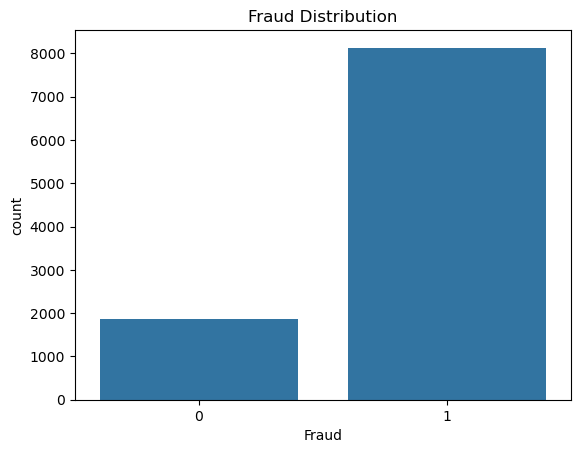

In [12]:
sns.countplot(x='Fraud', data=df)
plt.title("Fraud Distribution")
plt.show()

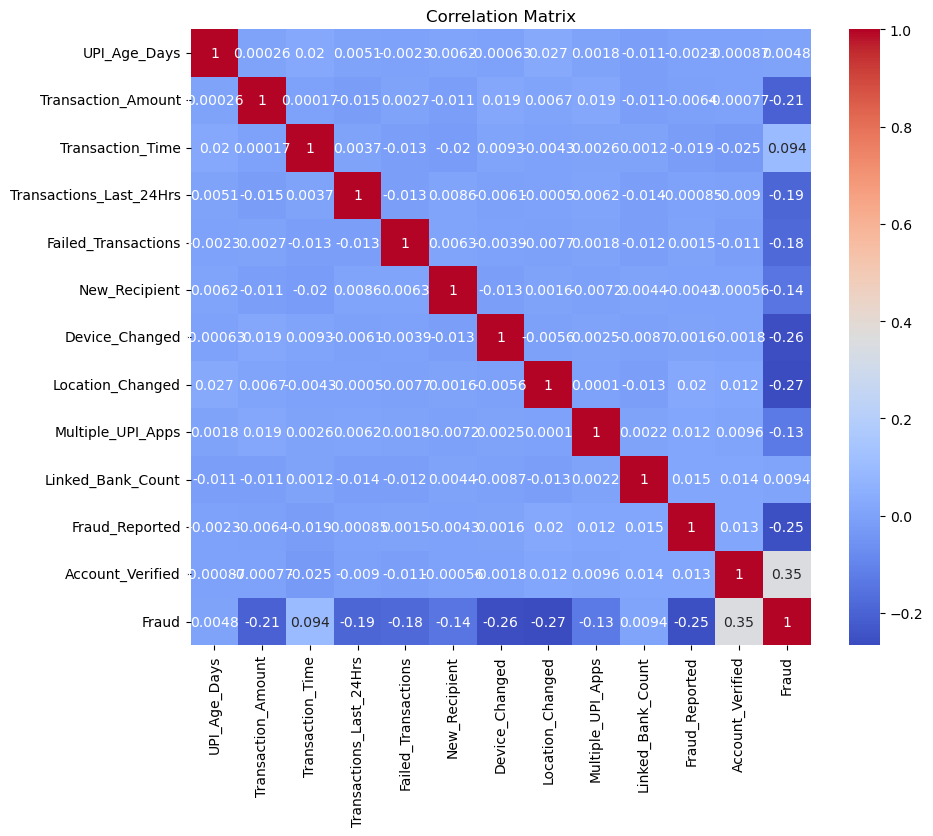

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

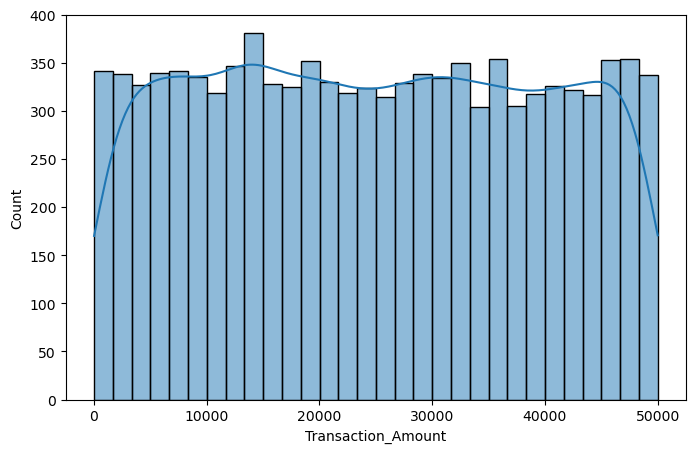

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Transaction_Amount'],bins=30,kde=True)
plt.show()

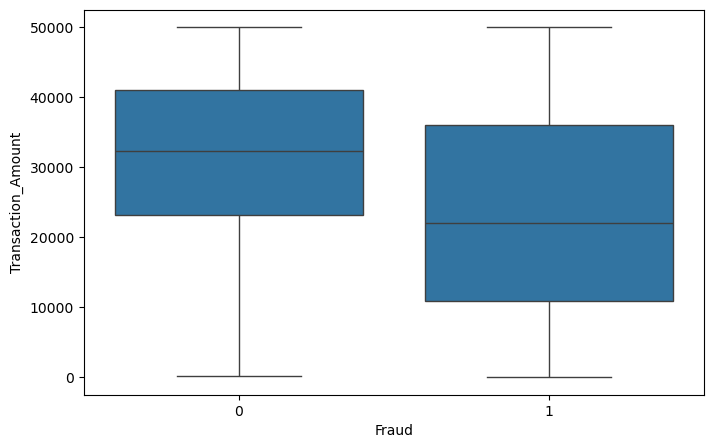

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Fraud',y='Transaction_Amount',data=df)
plt.show()

In [18]:
df['High_Amount'] = (df['Transaction_Amount'] > 20000).astype(int)

In [19]:
df['Night_Transaction'] = ((df['Transaction_Time'] >= 0)&(df['Transaction_Time'] <= 5)).astype(int)

In [20]:
df['High_Activity'] = (df['Transactions_Last_24Hrs'] > 20).astype(int)

In [21]:
df['Risky_Account'] = ((df['Fraud_Reported']==1)|(df['Account_Verified']==0)).astype(int)

In [23]:
df

,UPI_Age_Days,Transaction_Amount,Transaction_Time,Transactions_Last_24Hrs,Failed_Transactions,New_Recipient,Device_Changed,Location_Changed,Multiple_UPI_Apps,Linked_Bank_Count,Fraud_Reported,Account_Verified,Fraud,High_Amount,Night_Transaction,High_Activity,Risky_Account
0,3175,15805,14,42,7,0,0,0,0,5,0,1,1,0,0,1,0
1,1686,779,23,43,13,0,0,0,0,5,0,1,1,0,0,1,0
2,1083,18952,9,27,11,0,0,0,0,4,0,0,1,0,0,1,1
3,647,30750,8,38,1,1,1,0,0,5,0,1,1,1,0,1,0
4,3004,48565,7,46,2,1,0,0,0,2,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1259,38081,13,12,3,0,0,0,0,5,0,1,1,1,0,0,0
9996,45,19948,0,3,14,0,0,1,0,2,0,1,1,0,1,0,0
9997,606,4742,2,11,5,0,0,1,0,4,0,1,1,0,1,0,0
9998,416,27754,19,4,14,1,0,0,0,4,0,1,1,1,0,0,0


In [25]:
x = df.drop("Fraud", axis=1)
y = df["Fraud"]

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [28]:
print(x_train.shape)
print(x_test.shape)

(8000, 16)
(2000, 16)


In [29]:
rf = RandomForestClassifier(random_state=42)

In [30]:
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [32]:
y_pred = rf.predict(x_test)

In [33]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9845


In [34]:
precision = precision_score(y_test,y_pred)
print("Precision:", precision)

Precision: 0.98421372191864


In [35]:
recall = recall_score(y_test,y_pred)
print("Recall:", recall)

Recall: 0.9969249692496925


In [36]:
f1 = f1_score(y_test,y_pred)
print("F1:", f1)

F1: 0.9905285670638558


In [37]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96       374
           1       0.98      1.00      0.99      1626

    accuracy                           0.98      2000
   macro avg       0.99      0.96      0.97      2000
weighted avg       0.98      0.98      0.98      2000



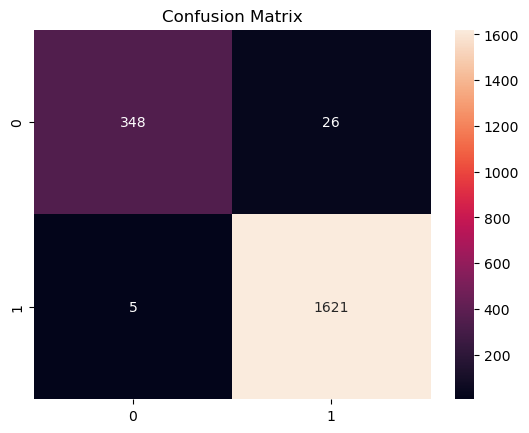

In [38]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [40]:
y_prob = rf.predict_proba(x_test)[:,1]
roc = roc_auc_score(y_test,y_prob)
print("ROC AUC Score:", roc)

ROC AUC Score: 0.9990010261065178


In [42]:
param_grid = {'n_estimators':[100,200],'max_depth':[5,10,15,None],'min_samples_split':[2,5],'min_samples_leaf':[1,2]}

In [44]:
grid = GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=param_grid,cv=5,scoring='accuracy',n_jobs=-1)

In [45]:
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [46]:
print(grid.best_params_)

{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [48]:
best_rf = grid.best_estimator_

In [49]:
y_pred_best = best_rf.predict(x_test)
print(accuracy_score(y_test,y_pred_best))

0.983


In [52]:
pip install shap

In [53]:
import shap

In [54]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(x_test)

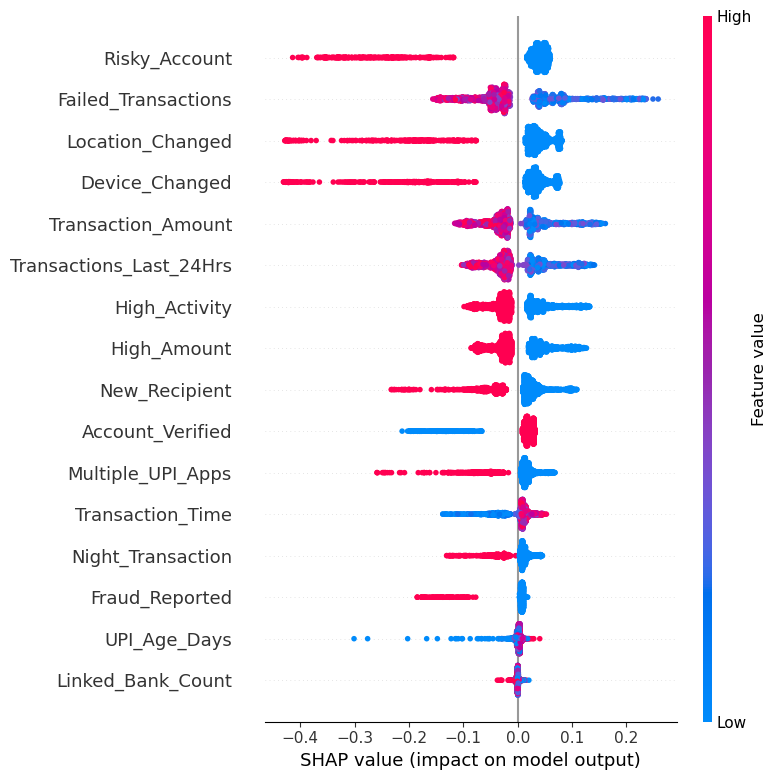

In [55]:
shap.summary_plot(shap_values[:,:,1],x_test)

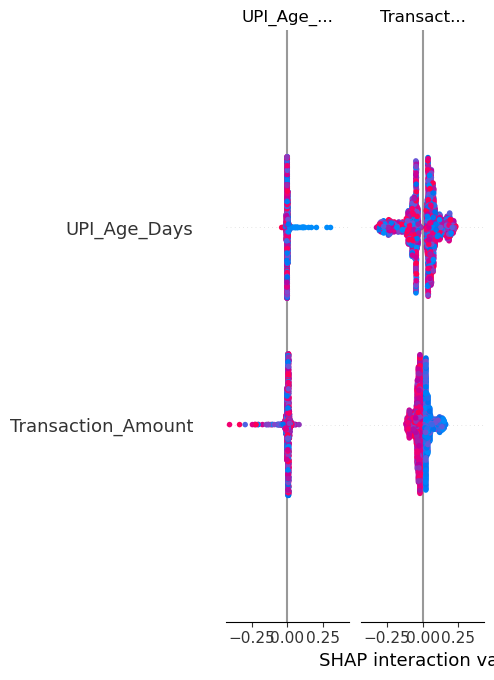

In [56]:
shap.summary_plot(shap_values,x_test,plot_type='bar')

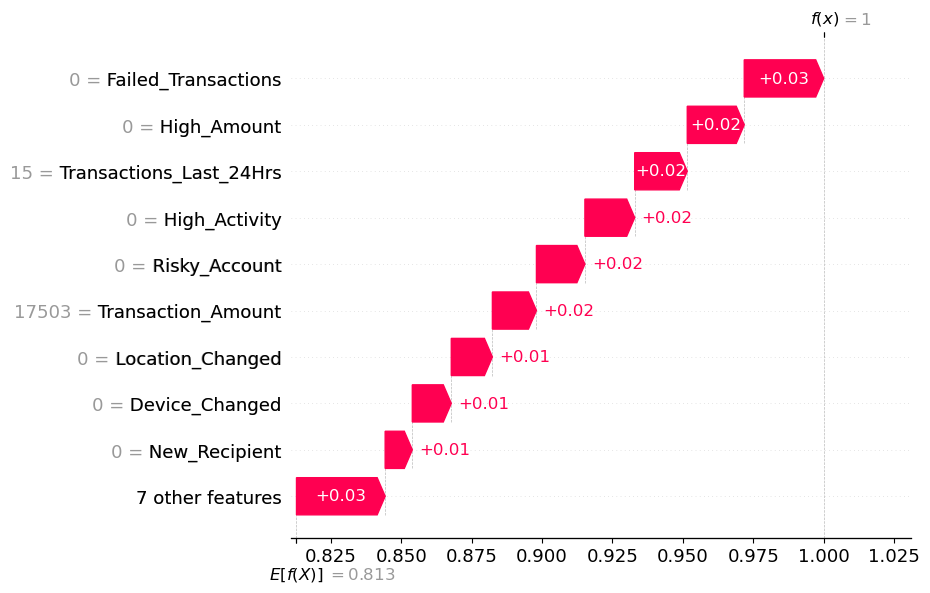

In [61]:
shap.plots.waterfall(shap.Explanation(values=shap_values[:,:,1][0],base_values=explainer.expected_value[1],data=x_test.iloc[0],feature_names=x_test.columns))

In [62]:
importance = pd.DataFrame({'Feature':x.columns,'Importance':best_rf.feature_importances_})
importance = importance.sort_values(by='Importance',ascending=False)
print(importance)

                    Feature  Importance
4       Failed_Transactions    0.121147
15            Risky_Account    0.118633
7          Location_Changed    0.098630
6            Device_Changed    0.092025
1        Transaction_Amount    0.089986
3   Transactions_Last_24Hrs    0.076778
11         Account_Verified    0.060455
5             New_Recipient    0.056027
14            High_Activity    0.047701
2          Transaction_Time    0.046303
12              High_Amount    0.044360
8         Multiple_UPI_Apps    0.042273
0              UPI_Age_Days    0.040818
10           Fraud_Reported    0.025859
13        Night_Transaction    0.024420
9         Linked_Bank_Count    0.014584


In [63]:
joblib.dump(best_rf,"upi_risk_score_model.pkl")

['upi_risk_score_model.pkl']

In [64]:
model = joblib.load("upi_risk_score_model.pkl")

In [65]:
sample = [[30,25000,2,30,7,1,1,1,1,2,1,0,1,1,1,1]]
prediction = model.predict(sample)
print(prediction)

[0]


C:\Users\KIIT\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
